In [40]:
#Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import least_squares
import pandas as pd

 
input_file = "/home/jesusavc/phd/odderon/scaling/elastic_pp_8TeVHEPData.csv"
df = pd.read_csv(input_file)

df.head()

df1 = df.copy()

In [41]:
# ============================================================
# Scaling parameters
# ============================================================
A_S = 0.065
A_T = 0.72
ALPHA = 0.305

# ============================================================
# Scaling function
# ============================================================
def compute_tstarstar(t_GeV2, sqrts_TeV, a_s=A_S, a_t=A_T):
    """
    Compute t** from |t| using the scaling formula:
    t** = (s/1TeV²)^0.065 * (|t|/1GeV²)^0.72
    
    Args:
        t_GeV2: |t| in GeV²
        sqrts_TeV: sqrt(s) in TeV
        a_s: exponent for s (default 0.065)
        a_t: exponent for t (default 0.72)
    
    Returns:
        t**: scaled variable
    """
    s_TeV2 = sqrts_TeV**2
    tstarstar = np.power(s_TeV2, a_s) * np.power(t_GeV2, a_t)
    return tstarstar

def compute_scaled_y(dsigma_dt, sqrts_TeV, alpha=ALPHA):
    """
    Compute scaled cross section:
    y = (s/1TeV²)^(-α) * dσ/dt
    
    Args:
        dsigma_dt: dσ/dt in mb/GeV²
        sqrts_TeV: sqrt(s) in TeV
        alpha: scaling exponent (default 0.305)
    
    Returns:
        y: scaled cross section
    """
    s_TeV2 = sqrts_TeV**2
    y = dsigma_dt / np.power(s_TeV2, alpha)
    return y



In [42]:
df1.head()

,$|t|$ [GeV$^2$],$|t|$ [GeV$^2$] LOW,$|t|$ [GeV$^2$] HIGH,d$\sigma$/d$t$ [mb/GeV$^2$],stat +,stat -,sys +,sys -
0,0.02850,0.02697,0.03005,305.09,0.527,-0.527,12.850,-12.850
1,0.03164,0.03005,0.03325,287.95,0.478,-0.478,12.080,-12.080
2,0.03491,0.03325,0.03658,269.24,0.436,-0.436,11.320,-11.320
3,0.03831,0.03658,0.04005,251.31,0.401,-0.401,10.590,-10.590
4,0.04184,0.04005,0.04365,235.15,0.371,-0.371,9.874,-9.874


In [43]:
output_csv = "/home/jesusavc/phd/odderon/scaling/scaled_data/TOTEM_data_8TeV_scaled.csv"
sqrts_TeV = 8.0

# Use t_star (corrected position) for scaling
t_values = df1['$|t|$ [GeV$^2$]'].values
dsigma_dt = df1['d$\sigma$/d$t$ [mb/GeV$^2$]'].values
dsigma_dt_err_stat = df1['stat +'].values
dsigma_dt_err_sys = df1['sys +'].values

# Compute scaled variables
tstarstar = compute_tstarstar(t_values, sqrts_TeV)
y = compute_scaled_y(dsigma_dt, sqrts_TeV)
y_err_stat = compute_scaled_y(dsigma_dt_err_stat, sqrts_TeV)
y_err_sys = compute_scaled_y(dsigma_dt_err_sys, sqrts_TeV)

# NEW: Compute total errors in quadrature
dsigma_dt_err_tot = np.sqrt(dsigma_dt_err_stat**2 + dsigma_dt_err_sys**2)
y_err_tot = np.sqrt(y_err_stat**2 + y_err_sys**2)

# Create output dataframe
df_scaled = pd.DataFrame({
    'sqrts_TeV': sqrts_TeV,
    't_star': t_values,
    'tstarstar': tstarstar,
    'y': y,
    'y_err_stat': y_err_stat,
    'y_err_sys': y_err_sys,
    'y_err_tot': y_err_tot,  # Error combinado para y
    'dsigma_dt': dsigma_dt,
    'dsigma_dt_err_stat': dsigma_dt_err_stat,
    'dsigma_dt_err_sys': dsigma_dt_err_sys,
    'dsigma_dt_err_tot': dsigma_dt_err_tot  # Error combinado para dsigma/dt
})

# Save to CSV
df_scaled.to_csv(output_csv, index=False, float_format='%.8f')

print(f"\nScaled data saved to: {output_csv}")
print(f"\nOutput columns:")
print(f"  sqrts_TeV: center-of-mass energy (TeV)")
print(f"  t_star: |t*| (GeV²)")
print(f"  tstarstar: t** scaled variable")
print(f"  y: scaled dσ/dt")
print(f"  y_err_stat: statistical uncertainty on y")
print(f"  y_err_sys: systematic uncertainty on y")
print(f"  y_err_tot: total uncertainty on y (in quadrature)")
print(f"  dsigma_dt: original dσ/dt (mb/GeV²)")
print(f"  dsigma_dt_err_stat: statistical uncertainty on dσ/dt")
print(f"  dsigma_dt_err_sys: systematic uncertainty on dσ/dt")
print(f"  dsigma_dt_err_tot: total uncertainty on dσ/dt (in quadrature)")

print(f"\nFirst few rows:")
print(df_scaled.head())
   
print(f"\nt** range: [{tstarstar.min():.4f}, {tstarstar.max():.4f}]")
print(f"y range: [{y.min():.6f}, {y.max():.6f}]")
    



Scaled data saved to: /home/jesusavc/phd/odderon/scaling/scaled_data/TOTEM_data_8TeV_scaled.csv

Output columns:
  sqrts_TeV: center-of-mass energy (TeV)
  t_star: |t*| (GeV²)
  tstarstar: t** scaled variable
  y: scaled dσ/dt
  y_err_stat: statistical uncertainty on y
  y_err_sys: systematic uncertainty on y
  y_err_tot: total uncertainty on y (in quadrature)
  dsigma_dt: original dσ/dt (mb/GeV²)
  dsigma_dt_err_stat: statistical uncertainty on dσ/dt
  dsigma_dt_err_sys: systematic uncertainty on dσ/dt
  dsigma_dt_err_tot: total uncertainty on dσ/dt (in quadrature)

First few rows:
   sqrts_TeV   t_star  tstarstar          y  y_err_stat  y_err_sys  y_err_tot  \
0        8.0  0.02850   0.101132  85.811023    0.148226   3.614250   3.617289   
1        8.0  0.03164   0.109037  80.990148    0.134444   3.397677   3.400336   
2        8.0  0.03491   0.117038  75.727687    0.122631   3.183916   3.186276   
3        8.0  0.03831   0.125137  70.684612    0.112787   2.978592   2.980727   
4   

In [44]:
df_scaled.tail()

,sqrts_TeV,t_star,tstarstar,y,y_err_stat,y_err_sys,y_err_tot,dsigma_dt,dsigma_dt_err_stat,dsigma_dt_err_sys,dsigma_dt_err_tot
63,8.0,0.826445,1.142341,0.006284,0.000394,0.000284,0.000486,0.022342,0.001400,0.001010,0.001726
64,8.0,0.879020,1.194210,0.005173,0.000453,0.000244,0.000514,0.018391,0.001610,0.000867,0.001829
65,8.0,0.920060,1.234097,0.005699,0.000481,0.000214,0.000526,0.020262,0.001710,0.000761,0.001872
66,8.0,0.971610,1.283500,0.004332,0.000346,0.000180,0.000390,0.015403,0.001230,0.000640,0.001387
67,8.0,1.033665,1.342008,0.002416,0.000262,0.000143,0.000299,0.008591,0.000932,0.000510,0.001062


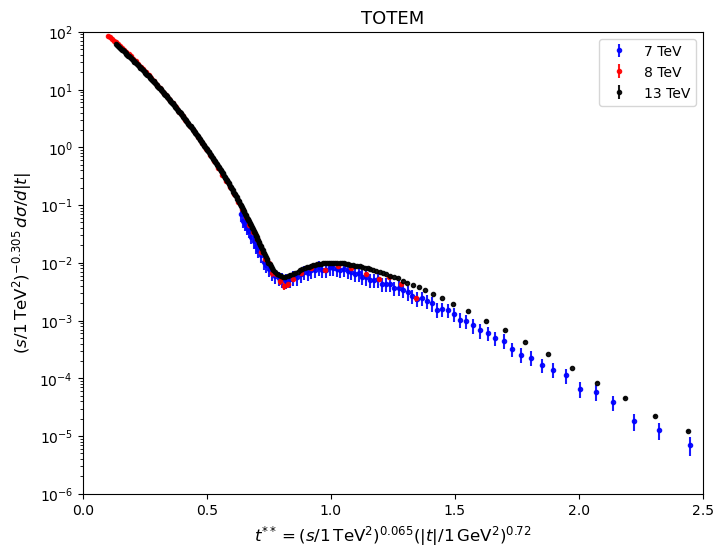

In [50]:
fname_totem="/home/jesusavc/phd/odderon/scaling/scaled_data/corrected_scaled_TOTEM.csv"


data_totem = np.loadtxt(fname_totem, delimiter=',', skiprows=1)
sqrts_totem = data_totem[:, 0]
tau_totem   = data_totem[:, 2]
y_totem     = data_totem[:, 3]
yerr_totem  = data_totem[:, 6]

# 1. Initialize the figure and axis
fig, ax1 = plt.subplots(figsize=(8, 6), dpi=100)

# 2. Apply your axis scaling
ax1.set_yscale("log")

colors_totem = ["blue", "red", "black"]

for i, E in enumerate(sorted(np.unique(sqrts_totem))):
        mE = np.isclose(sqrts_totem, E)
        ax1.errorbar(
            tau_totem[mE], y_totem[mE], yerr=yerr_totem[mE],
            fmt="o",
            color=colors_totem[i % len(colors_totem)],
            markersize=3,
            capsize=0,
            elinewidth=1.5,
            alpha=0.9,
            label=f"{E:g} TeV"
        )

# 4. Format the plot   
ax1.set_xlabel(r"$t^{**}=(s/1\,\mathrm{TeV}^2)^{0.065}(|t|/1\,\mathrm{GeV}^2)^{0.72}$", fontsize=12)
ax1.set_ylabel(r"$(s/1\,\mathrm{TeV}^2)^{-0.305}\, d\sigma/d|t|$", fontsize=12)
ax1.set_title("TOTEM", fontsize=13)
ax1.legend(fontsize=10)
ax1.set_xlim(0.0, 2.5)
ax1.set_ylim(1e-6, 1e2)

# 5. Display the plot (for Jupyter Notebooks)
plt.show()
 